# **Section 1: Data Preparation**

In [ ]:
!pip install xarray zarr gcsfs

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

**Q1. Load the dataset using xarray and inspect its structure**

In [ ]:
import xarray as xr

ds = xr.open_zarr(
    "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr",
    storage_options={"token": "anon"}
)

print(ds)

<xarray.Dataset> Size: 47TB
Dimensions:                                           (time: 93544,
                                                       latitude: 721,
                                                       longitude: 1440,
                                                       level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * latitude                                          (latitude) float32 3kB ...
  * longitude                                         (longitude) float32 6kB ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/50)
    10m_u_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_dewpoint_temperature  

In [ ]:
print(ds.data_vars)

Data variables:
    10m_u_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_temperature                                    (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    boundary_layer_height                             (time, latitude, longitude) float32 388GB dask.array

**Q2. Convert temperature from Kelvin to Celsius**

In [ ]:
temp_c = ds["2m_temperature"] - 273.15

print(temp_c)

<xarray.DataArray '2m_temperature' (time: 93544, latitude: 721, longitude: 1440)> Size: 388GB
dask.array<sub, shape=(93544, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
sample = temp_c.isel(
    time=0,
    latitude=360,
    longitude=720
).compute()

print(sample.values)

26.807587


# **Section 2: Time Series Analysis (Single Location)**

**Q3. Select a single geographic location (e.g., near Odisha: lat ≈ 20, lon ≈ 85)**

In [ ]:
temp_c = (
    ds["2m_temperature"]
    .sel(time=slice("2022-01-01", "2022-12-31"))
    - 273.15
)

In [ ]:
temp_c.shape

(1460, 721, 1440)

In [ ]:
odisha_temp = temp_c.sel(
    latitude=20,
    longitude=85,
    method="nearest"
)

print(odisha_temp)

<xarray.DataArray '2m_temperature' (time: 1460)> Size: 6kB
dask.array<getitem, shape=(1460,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 12kB 2022-01-01 ... 2022-12-31T18:00:00
    latitude   float32 4B 20.0
    longitude  float32 4B 85.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print("Latitude:", odisha_temp.latitude.values)
print("Longitude:", odisha_temp.longitude.values)

Latitude: 20.0
Longitude: 85.0


In [ ]:
odisha_temp.shape

(1460,)

In [ ]:
print(odisha_temp.time.min().values)
print(odisha_temp.time.max().values)

2022-01-01T00:00:00.000000000
2022-12-31T18:00:00.000000000


**Q4. Plot temperature vs time for this location**

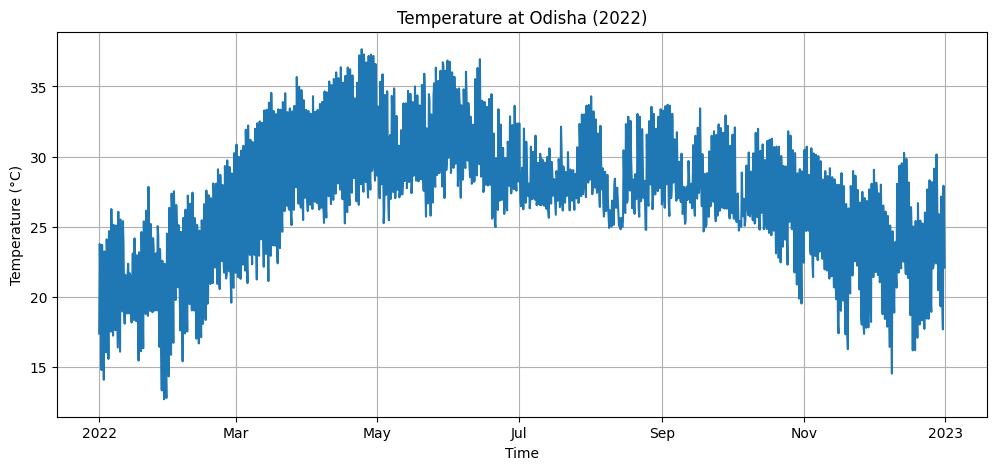

In [ ]:
plt.figure(figsize=(12,5))

odisha_temp.plot()

plt.title("Temperature at Odisha (2022)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

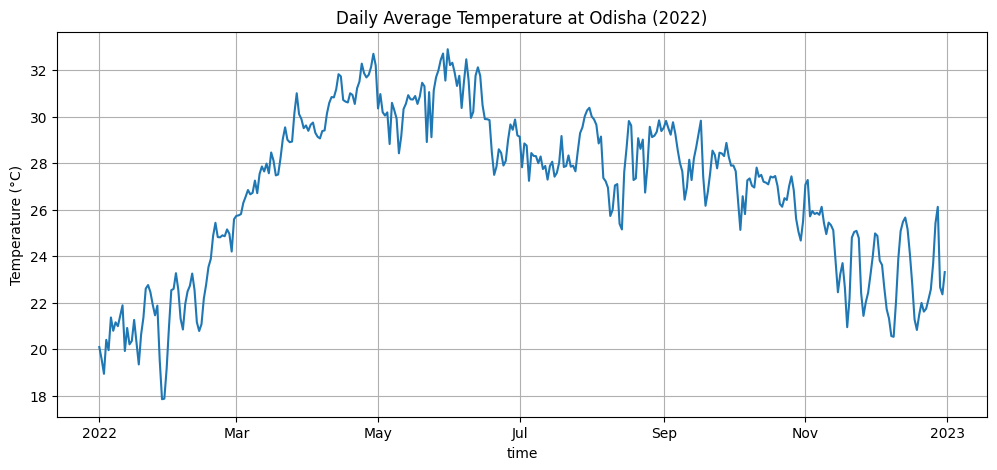

In [ ]:
plt.figure(figsize=(12,5))
odisha_temp.resample(time="1D").mean().plot()
plt.title("Daily Average Temperature at Odisha (2022)")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [ ]:
bpd_temp = temp_c.sel(
    latitude=21.9320,
    longitude=86.7466,
    method="nearest"
)

print(bpd_temp)

<xarray.DataArray '2m_temperature' (time: 1460)> Size: 6kB
dask.array<getitem, shape=(1460,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 12kB 2022-01-01 ... 2022-12-31T18:00:00
    latitude   float32 4B 22.0
    longitude  float32 4B 86.75
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print("Latitude:", bpd_temp.latitude.values)
print("Longitude:", bpd_temp.longitude.values)

Latitude: 22.0
Longitude: 86.75


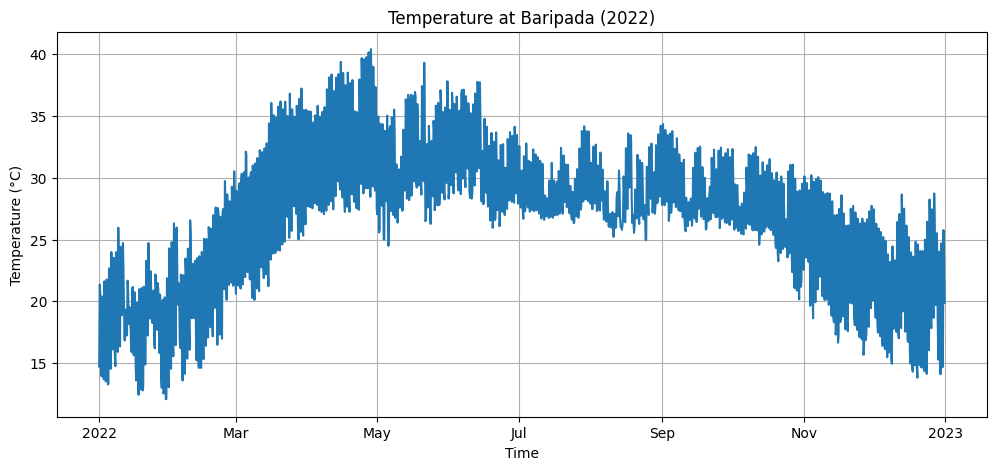

In [ ]:
plt.figure(figsize=(12,5))

bpd_temp.plot()

plt.title("Temperature at Baripada (2022)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

In [ ]:
drgbd_temp = temp_c.sel(
    latitude=19.9037,
    longitude=84.1303,
    method="nearest"
)

print(drgbd_temp)

<xarray.DataArray '2m_temperature' (time: 1460)> Size: 6kB
dask.array<getitem, shape=(1460,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 12kB 2022-01-01 ... 2022-12-31T18:00:00
    latitude   float32 4B 20.0
    longitude  float32 4B 84.25
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print("Latitude:", drgbd_temp.latitude.values)
print("Longitude:", drgbd_temp.longitude.values)

Latitude: 20.0
Longitude: 84.25


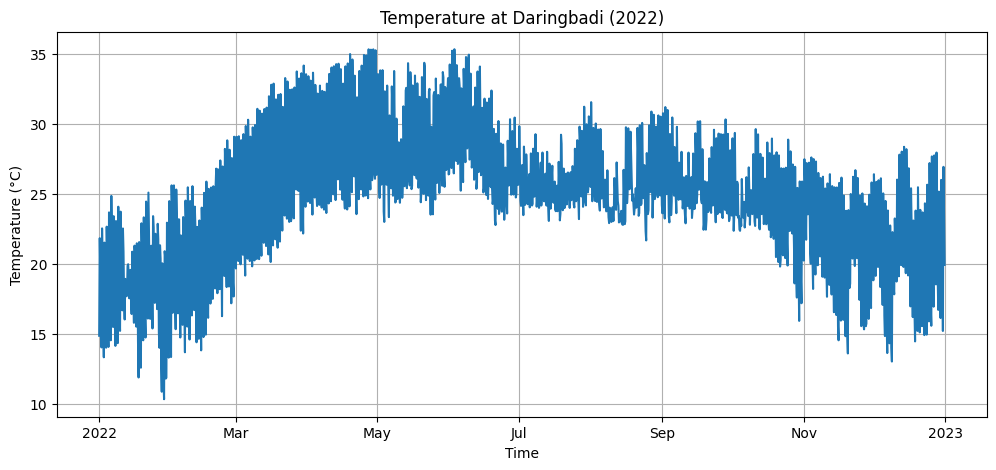

In [ ]:
plt.figure(figsize=(12,5))

drgbd_temp.plot()

plt.title("Temperature at Daringbadi (2022)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

**Q5. Compute Maximum, Minimum, and Mean Temperature**

In [ ]:
max_temp = odisha_temp.max().compute().item()
min_temp = odisha_temp.min().compute().item()
mean_temp = odisha_temp.mean().compute().item()

print("Maximum Temperature:", max_temp, "°C")
print("Minimum Temperature:", min_temp, "°C")
print("Mean Temperature:", mean_temp, "°C")

Maximum Temperature: 37.652587890625 °C
Minimum Temperature: 12.7218017578125 °C
Mean Temperature: 26.893369674682617 °C


In [ ]:
max_temp = bpd_temp.max().compute().item()
min_temp = bpd_temp.min().compute().item()
mean_temp = bpd_temp.mean().compute().item()

print("Maximum Temperature:", max_temp, "°C")
print("Minimum Temperature:", min_temp, "°C")
print("Mean Temperature:", mean_temp, "°C")

Maximum Temperature: 40.4039306640625 °C
Minimum Temperature: 12.080902099609375 °C
Mean Temperature: 26.714393615722656 °C


In [ ]:
max_temp = drgbd_temp.max().compute().item()
min_temp = drgbd_temp.min().compute().item()
mean_temp = drgbd_temp.mean().compute().item()

print("Maximum Temperature:", max_temp, "°C")
print("Minimum Temperature:", min_temp, "°C")
print("Mean Temperature:", mean_temp, "°C")

Maximum Temperature: 35.3077392578125 °C
Minimum Temperature: 10.363616943359375 °C
Mean Temperature: 24.623538970947266 °C


**Q6. Briefly describe the pattern**

The temperature time series exhibits a clear seasonal pattern. Temperatures gradually increase from January and reach their highest values during April and May, with a maximum temperature of approximately 37.65°C. After the summer season, temperatures decrease gradually through the monsoon and winter months. Short-term fluctuations are visible due to daily weather variability and the 6-hourly sampling frequency. Overall, the variation is relatively smooth and follows expected seasonal temperature changes for a tropical coastal region.

# **Section 3: Spatial Analysis (Single Time Step)**

**Q7. Select temperature data for a single time step**

In [ ]:
temp_snapshot = temp_c.isel(time=0)

print(temp_snapshot)

<xarray.DataArray '2m_temperature' (latitude: 721, longitude: 1440)> Size: 4MB
dask.array<getitem, shape=(721, 1440), dtype=float32, chunksize=(721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 2022-01-01
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print(temp_c.time[0].values)

2022-01-01T00:00:00.000000000


**Q8. Plot a 2D temperature map**

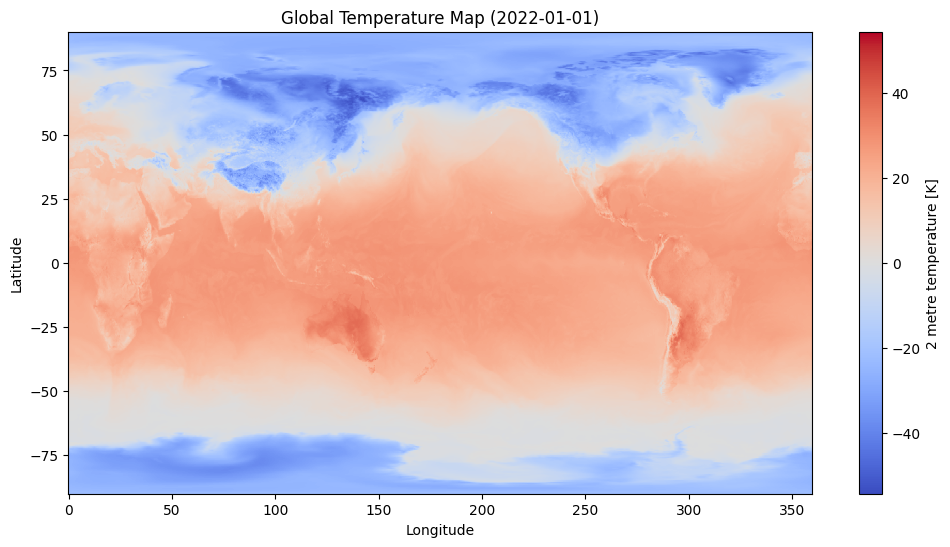

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

temp_snapshot.plot(
    cmap="coolwarm"
)

plt.title("Global Temperature Map (2022-01-01)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

**Q9. Interpret the Temperature Map**

The temperature map shows a clear spatial variation in global temperatures. Regions near the equator appear warmer, while polar regions are significantly cooler. Large parts of the Northern Hemisphere, including Canada, Greenland, and Siberia, exhibit low temperatures because January corresponds to winter in that hemisphere. In contrast, Australia, southern Africa, and parts of South America appear warmer due to summer conditions in the Southern Hemisphere. Overall, the map demonstrates the strong influence of latitude and seasonal cycles on global temperature distribution.

# **Section 4: Heatwave Detection**

**Q10. Define a heatwave condition**

A heatwave was defined as any time step where the 2-meter air temperature exceeded 35°C. This threshold was chosen to identify unusually hot periods within the selected location.

In [ ]:
HEATWAVE_THRESHOLD = 35

**Q11. Create a Boolean Mask**

In [ ]:
heatwave_mask = odisha_temp > HEATWAVE_THRESHOLD

print(heatwave_mask)

<xarray.DataArray '2m_temperature' (time: 1460)> Size: 1kB
dask.array<gt, shape=(1460,), dtype=bool, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 12kB 2022-01-01 ... 2022-12-31T18:00:00
    latitude   float32 4B 20.0
    longitude  float32 4B 85.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print(heatwave_mask.compute())

<xarray.DataArray '2m_temperature' (time: 1460)> Size: 1kB
array([False, False, False, ..., False, False, False])
Coordinates:
  * time       (time) datetime64[ns] 12kB 2022-01-01 ... 2022-12-31T18:00:00
    latitude   float32 4B 20.0
    longitude  float32 4B 85.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


**Q12. Count the Number of Heatwave Days**

In [ ]:
daily_max = odisha_temp.resample(time="1D").max()

In [ ]:
heatwave_days = (daily_max > HEATWAVE_THRESHOLD).sum()

print("Heatwave Days:", heatwave_days.compute().item())

Heatwave Days: 40


**Q13. Plot Temperature and Highlight Heatwave Periods**

In [ ]:
odisha_temp_local = odisha_temp.compute()

heatwave_points = odisha_temp_local.where(
    odisha_temp_local > 35,
    drop=True
)

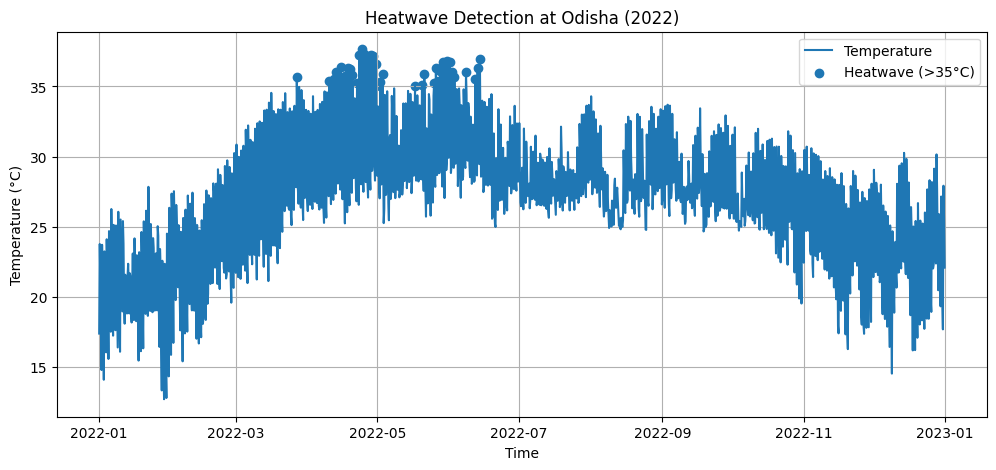

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    odisha_temp_local.time,
    odisha_temp_local,
    label="Temperature"
)

plt.scatter(
    heatwave_points.time,
    heatwave_points,
    label="Heatwave (>35°C)"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Heatwave Detection at Odisha (2022)")
plt.legend()
plt.grid(True)

plt.show()

# **Section 5: Spatio-Temporal Aggregation**

**Q14. Compute the average temperature across all locations for each time step**

In [ ]:
global_avg_temp = temp_c.mean(
    dim=["latitude", "longitude"]
)

print(global_avg_temp)

<xarray.DataArray '2m_temperature' (time: 1460)> Size: 6kB
dask.array<mean_agg-aggregate, shape=(1460,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 ... 2022-12-31T18:00:00
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print(global_avg_temp.isel(time=slice(0,5)).compute())

<xarray.DataArray '2m_temperature' (time: 5)> Size: 20B
array([3.6525977, 3.8771691, 4.14582  , 3.8781118, 3.5884364],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 40B 2022-01-01 ... 2022-01-02
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


**Q15. Plot this as a time series**

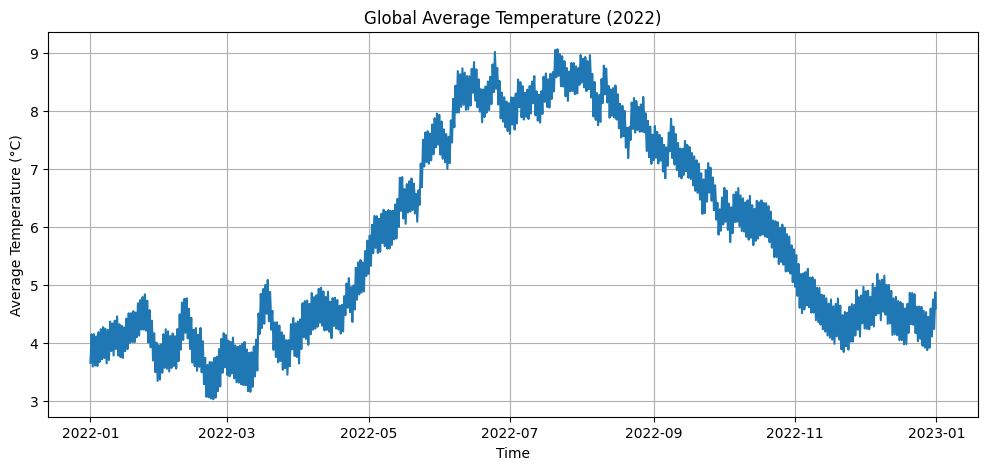

In [ ]:
global_avg_temp_local = global_avg_temp.compute()

plt.figure(figsize=(12,5))

plt.plot(
    global_avg_temp_local.time,
    global_avg_temp_local
)

plt.title("Global Average Temperature (2022)")
plt.xlabel("Time")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)

plt.show()

**Q16. Explain what this plot represents**

The plot represents the average near-surface temperature across all locations in the WeatherBench2 dataset for each time step during 2022. Unlike the Odisha time series, this graph summarizes the overall thermal state of the Earth rather than a single location. The temperature increases from January to mid-year, reaches a peak during July–August, and then decreases toward the end of the year. This pattern reflects the seasonal cycle of global temperature, with warmer conditions during Northern Hemisphere summer and cooler conditions during winter.

# **Section 6: Comparative Analysis**

**Q17. Select Two Locations**

In [ ]:
inland_temp = temp_c.sel(
    latitude=21.15,
    longitude=79.08,
    method="nearest"
)

coastal_temp = temp_c.sel(
    latitude=19.81,
    longitude=85.83,
    method="nearest"
)

**Q18. Plot and Compare**

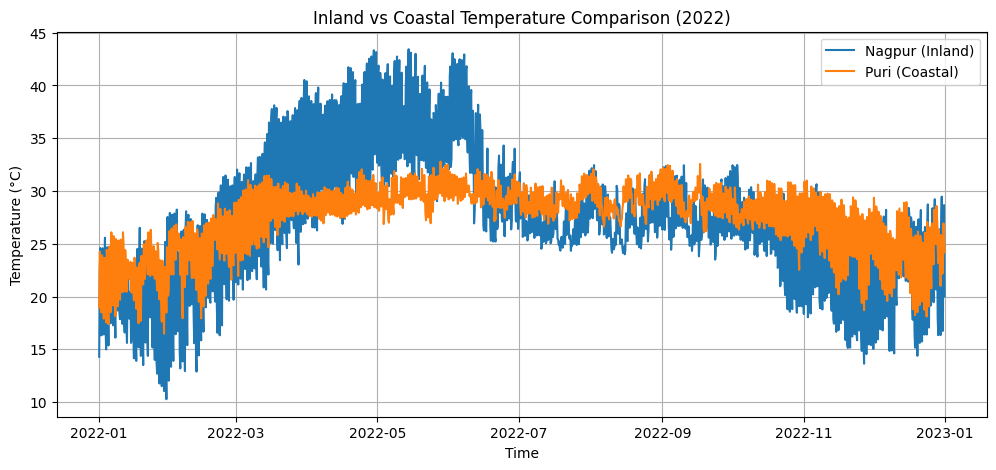

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    inland_temp.time,
    inland_temp,
    label="Nagpur (Inland)"
)

plt.plot(
    coastal_temp.time,
    coastal_temp,
    label="Puri (Coastal)"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Inland vs Coastal Temperature Comparison (2022)")
plt.legend()
plt.grid(True)

plt.show()

**Q19. Briefly describe the differences observed**

The inland location (Nagpur) exhibits significantly larger temperature variations throughout the year compared to the coastal location (Puri). During summer, Nagpur reaches temperatures above 40°C, whereas Puri remains close to 30–32°C. In winter, Nagpur experiences much lower temperatures, while Puri remains relatively warm. This difference occurs because the Bay of Bengal moderates temperatures in coastal regions, reducing both summer heating and winter cooling. As a result, the coastal temperature profile is smoother and more stable than the inland temperature profile.
